## Product-type 1 - 통계
- 데이터 로드
- 기술 통계량 확인
    - process 관련 데이터 (공정 변수)
    - sensor 관련 데이터 (센서 변수)
    - 전체 샘플 수 대비 불량률
- 정규성 검정
    - Shapiro-Wilk 검정
    - Q-Q Plot
- 등분산성 검정
    - Levene 검정
- 스피어만 상관계수 히트맵
    - process 관련 데이터 (공정 변수)
    - sensor 관련 데이터 (센서 변수)
- 전체 샘플 수 대비 불량 제품의 비율
- Box-Plot
    - 공정/센서변수 
- Welch's T-test
    - 공정/센서변수
- Mann-Whitney U 검정
    - 공정/센서변수     

In [1]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 분석/통계
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display
import warnings
import platform

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# matplotlib 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.figsize'] = (12, 6)

# seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


---
---
### 1. 데이터 로드

In [2]:
# 1. 전처리가 완료된 Process, Sensor, Defects 관련 데이터 로드
df_process_1 = pd.read_csv('data/for_process_data_product-1.csv')
df_sensor_1 = pd.read_csv('data/for_sensor_data_product-1.csv')
df_defects_1 = pd.read_csv('data/for_defects_data_product-1.csv')
df_original_1 = pd.read_csv('data/for_entire_data_product-1.csv')

In [3]:
# 2. 데이터 크기 확인
print(f"제품 1의 전체 데이터 크기: {df_original_1.shape}")

print(f"제품 1의 process 관련 데이터 크기: {df_process_1.shape}")
print(f"제품 1의 sensor 관련 데이터 크기: {df_sensor_1.shape}")
print(f"제품 1의 defects 관련 데이터 크기: {df_defects_1.shape}")

제품 1의 전체 데이터 크기: (4207, 24)
제품 1의 process 관련 데이터 크기: (4207, 15)
제품 1의 sensor 관련 데이터 크기: (4207, 6)
제품 1의 defects 관련 데이터 크기: (4207, 3)


In [4]:
# 3-1. 불량 유무로 불량 컬럼 통일 -> is_defect 컬럼 생성
# 행을 기준으로 1이 존재하면 불량으로 처리할 예정
defect_cols = ['surface_defect', 'structural_defect', 'contamination_defect']

# 3-2. 결함과 관련된 데이터프레임
df_defects_1['is_defect'] = df_defects_1[defect_cols].max(axis=1)
# 불량유형을 is_defect로 통합하고, 개별 불량 유형 컬럼은 삭제
df_defects_1_1 = df_defects_1.drop(columns=defect_cols)

display(df_defects_1_1.head(5))

,is_defect
0,0
1,0
2,0
3,1
4,0


In [5]:
# 3-4. 전체 데이터프레임
df_original_1['is_defect'] = df_original_1[defect_cols].max(axis=1)
# 불량유형을 is_defect로 통합하고, 개별 불량 유형 컬럼은 삭제
df_original_1_1 = df_original_1.drop(columns=defect_cols)

display(df_original_1_1.head(5))

,shot_key,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,is_defect
0,1_1,0.144,0.170,0.188,2.134,214,0.008,10,258,20.7,0.044,1037,7.8,0.7,0.8,695.0,6.3,26.0,2.71,32.9,58.4,0
1,1002_2,0.144,0.170,0.182,2.124,217,0.008,11,257,20.7,0.044,1052,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0
2,2003_3,0.144,0.170,0.182,2.116,214,0.008,11,257,20.8,0.041,1037,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0
3,3004_4,0.144,0.170,0.182,2.137,217,0.008,11,257,20.7,0.043,1051,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,1
4,4005_5,0.144,0.172,0.176,2.111,217,0.008,12,257,20.7,0.042,1052,7.8,0.7,0.8,697.9,6.4,26.1,2.69,32.9,57.8,0


In [6]:
# 3-6. 머신러닝을 위한 데이터 저장 (주석을 해제하면 저장 가능)
# df_original_1_1.to_csv("../data/ML_modeling_data_product-1.csv", index=False)

---
---
### 2. 기술통계

#### 2.1 기술통계량 및 불량률 확인

In [7]:
# 1. 기술통계
def create_statistics_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name} 변수 기술통계량")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 기술 통계량
    stats_df = df_copied.describe().T
    stats_df['Skewness'] = df_copied.skew()
    
    # 컬럼명 한글로 변경
    stats_df.rename(columns={
        'count': '개수',
        'mean': '평균',
        'std': '표준편차',
        'min': '최솟값',
        '25%': 'Q1의 경계값',
        '50%': '중앙값',
        '75%': 'Q3의 경계값',
        'max': '최댓값',
        'Skewness': '왜도'
    }, inplace=True)
    
    display(stats_df)

In [ ]:
create_statistics_summary(df_process_1, "공정(process)")
create_statistics_summary(df_sensor_1, "센서(sensor)")


공정(process) 변수 기술통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,왜도
velocity_1,4207.0,0.143272,0.004151,0.134,0.142,0.142,0.144,0.180,4.422801
velocity_2,4207.0,0.168944,0.005202,0.162,0.168,0.168,0.170,0.212,5.413094
velocity_3,4207.0,0.182449,0.006850,0.172,0.178,0.182,0.186,0.234,3.064106
high_velocity,4207.0,2.134074,0.081259,0.000,2.120,2.137,2.152,2.285,-19.158455
cylinder_pressure,4207.0,219.793202,8.888864,107.000,215.000,217.000,218.000,241.000,-0.587423
rapid_rise_time,4207.0,0.007963,0.001266,0.000,0.008,0.008,0.008,0.021,3.769409
biscuit_thickness,4207.0,11.715237,1.529924,0.000,11.000,12.000,12.000,22.000,-1.761872
clamping_force,4207.0,255.877110,2.465235,238.000,254.000,257.000,258.000,263.000,-0.895664
cycle_time,4207.0,21.432113,6.411477,20.200,20.700,20.900,21.200,218.600,24.49784
pressure_rise_time,4207.0,0.041492,0.003257,0.000,0.041,0.043,0.044,0.046,-2.955792



환경(sensor) 변수 기술통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,왜도
melting_furnace_temp,4207.0,700.388614,14.365077,671.00,689.15,701.20,710.65,730.00,0.037698
air_pressure,4207.0,6.100903,0.623627,4.60,5.80,6.20,6.60,7.10,-0.588247
coolant_temp,4207.0,26.756382,0.491092,25.90,26.40,26.70,27.10,28.10,0.628650
coolant_pressure,4207.0,2.710183,0.047140,2.59,2.69,2.72,2.75,2.79,-0.870506
factory_temp,4207.0,33.015997,1.748600,30.60,32.00,32.20,34.50,37.00,0.935854
factory_humidity,4207.0,60.528548,7.051350,45.50,57.40,62.50,65.60,70.70,-0.788468


In [9]:
# 2. 전체 샘플 수 & 불량률
total    = len(df_original_1_1)
n_defect = df_original_1_1["is_defect"].sum() # 불량제품
n_normal = total - n_defect # 정상 제품
rate     = n_defect / total * 100

print(f"=== 전체 데이터 대비 불량률 ===")
print(f"\n전체 샘플: {total:,}개")
print(f"불량인 제품: {int(n_defect):,}개")
print(f"정상인 제품: {int(n_normal):,}개")
print(f"불량률: {rate:.2f}%")
print('='*28)

=== 전체 데이터 대비 불량률 ===

전체 샘플: 4,207개
불량인 제품: 739개
정상인 제품: 3,468개
불량률: 17.57%


#### **2.2 기술통계 해석** 
**1. 불량인 제품의 개수와 비율 확인**\
Product type 1 데이터는 총 4,207개의 관측치로 구성되어 있으며,\
정상인 제품이 3,468개, 불량인 제품이 739개이므로 불량률이 **약 17.57%**이다.\
정상 비율이 더 높지만 불량 비중도 무시하기 어려운 수준이므로, 이후 정상/불량 비교 통계에서도 두 집단의 차이를 함께 살펴볼 필요가 있다.


**2. 공정관련 변수 (df_process) 데이터 기술통계량 해석**\
공정 변수 대부분은 평균과 중앙값의 차이가 크지 않고, 값이 비교적 좁은 범위에 분포하여 전반적으로는 안정적인 편이다.\
다만, `cycle_time`은 최대값이 매우 크게 나타나고, `high_velocity`, `rapid_rise_time` 등은 일부 0값의 영향이 확인되어 분포가 치우친 변수들이 존재한다.\
따라서 제품유형 1의 공정 변수는 모든 변수가 균일한 정규형 분포를 따른다기보다, 일부 변수는 안정적이고 일부 변수는 치우침과 극단값의 영향을 함께 가지는 구조로 해석하는 것이 적절하다.

**3. 센서관련 변수(df_sensor) 데이터 기술통계량 해석**\
센서 변수는 전체적으로 공정 변수보다 비교적 안정적인 편이다.\
다만 `factory_temp`, `factory_humidity` 등은 분포의 치우침이 상대적으로 크게 나타난다.\
따라서 센서 변수도 단순 안정적이라고만 보기보다, 일부 변수에서 비대칭성이 존재한다고 해석하는 것이 적절하다.

**4. 기술통계량 해석 종합**\
제품유형 1 데이터는 정상 제품이 더 많지만 불량 비율도 약 17% 수준으로 나타나, 품질 비교 분석의 의미가 충분하다.\
기술통계량만 보았을 때 공정/센서 변수 모두 일부 변수에서 비대칭성과 극단값의 영향이 확인되므로,\
이후 정규성 검정, 등분산성 검정등으로 정상과 불량 간 차이를 추가로 확인하는 흐름이 타당하다.

---
---
### 3. 정규성 검정

#### 3.1 Shapiro-Wilk 검정

In [10]:
# 1. 연속형 변수 정규성 검정 (Shapiro-Wilk)
def create_shapiro_summary(df, df_name, exclude_cols=None, alpha=0.05):
    """Shapiro-Wilk 정규성 검정"""
    print(f"\n{'='*80}")
    print(f"제품 1의 {df_name} 관련 데이터 정규성 검정 (Shapiro-Wilk)")
    print(f"{'='*80}\n")

    # exclude_cols에 속한 컬럼 제외
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')

    # 출력값 저장
    result_list = []

    # 각 컬럼별 정규성 검정
    for col in df_copied.columns:
        series = df_copied[col].dropna()

        # 정규성 확인: Shapiro-Wilk
        stat, p_value = stats.shapiro(series)

        # H0: 정규성을 만족한다.
        # H1: 정규성을 불만족한다.
        if p_value >= alpha:
            result = "정규성 만족"
        else:
            result = "정규성 불만족"

        # 출력값
        result_list.append([
            col, 
            stat, 
            p_value, 
            result])

    # 출력
    shapiro_df = pd.DataFrame(
        result_list, 
        columns=[
            "변수명", 
            "Shapiro 검정통계량", 
            "p-value", 
            "판정"
        ]
    ).set_index("변수명")
    
    display(shapiro_df)
    
    return shapiro_df

In [11]:
# 2. 함수 실행
shapiro_df_original_1 = create_shapiro_summary(
    df_original_1_1,
    "공정/센서",
    exclude_cols=['shot_key', 'is_defect',]
)


제품 1의 공정/센서 관련 데이터 정규성 검정 (Shapiro-Wilk)



,Shapiro 검정통계량,p-value,판정
변수명,,,
velocity_1,0.569715,6.265147e-73,정규성 불만족
velocity_2,0.416442,2.610597e-79,정규성 불만족
velocity_3,0.748749,2.476649e-62,정규성 불만족
high_velocity,0.230170,2.389708e-85,정규성 불만족
cylinder_pressure,0.591752,7.414507e-72,정규성 불만족
rapid_rise_time,0.576706,1.355708e-72,정규성 불만족
biscuit_thickness,0.730327,1.119151e-63,정규성 불만족
clamping_force,0.918851,7.542148e-43,정규성 불만족
cycle_time,0.052007,4.916468e-90,정규성 불만족


#### 3.2 Q-Q Plot

In [12]:
# 1. Q-Q plot
def plot_qq_table(df, title=None, exclude_cols=None):
    """Q-Qplot 그래프"""
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼 전체 선택
    cols = df_copied.select_dtypes(include='number').columns.tolist()
    
    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    axes = axes.flatten()
    
    for i, col in enumerate(cols[:16]):
        series = df_copied[col].dropna()
        # Q-Q plot
        stats.probplot(series, dist="norm", plot=axes[i])
        axes[i].set_title(col)
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    if title:
        fig.suptitle(title, y=1.02)
    
    plt.tight_layout()
    plt.show()

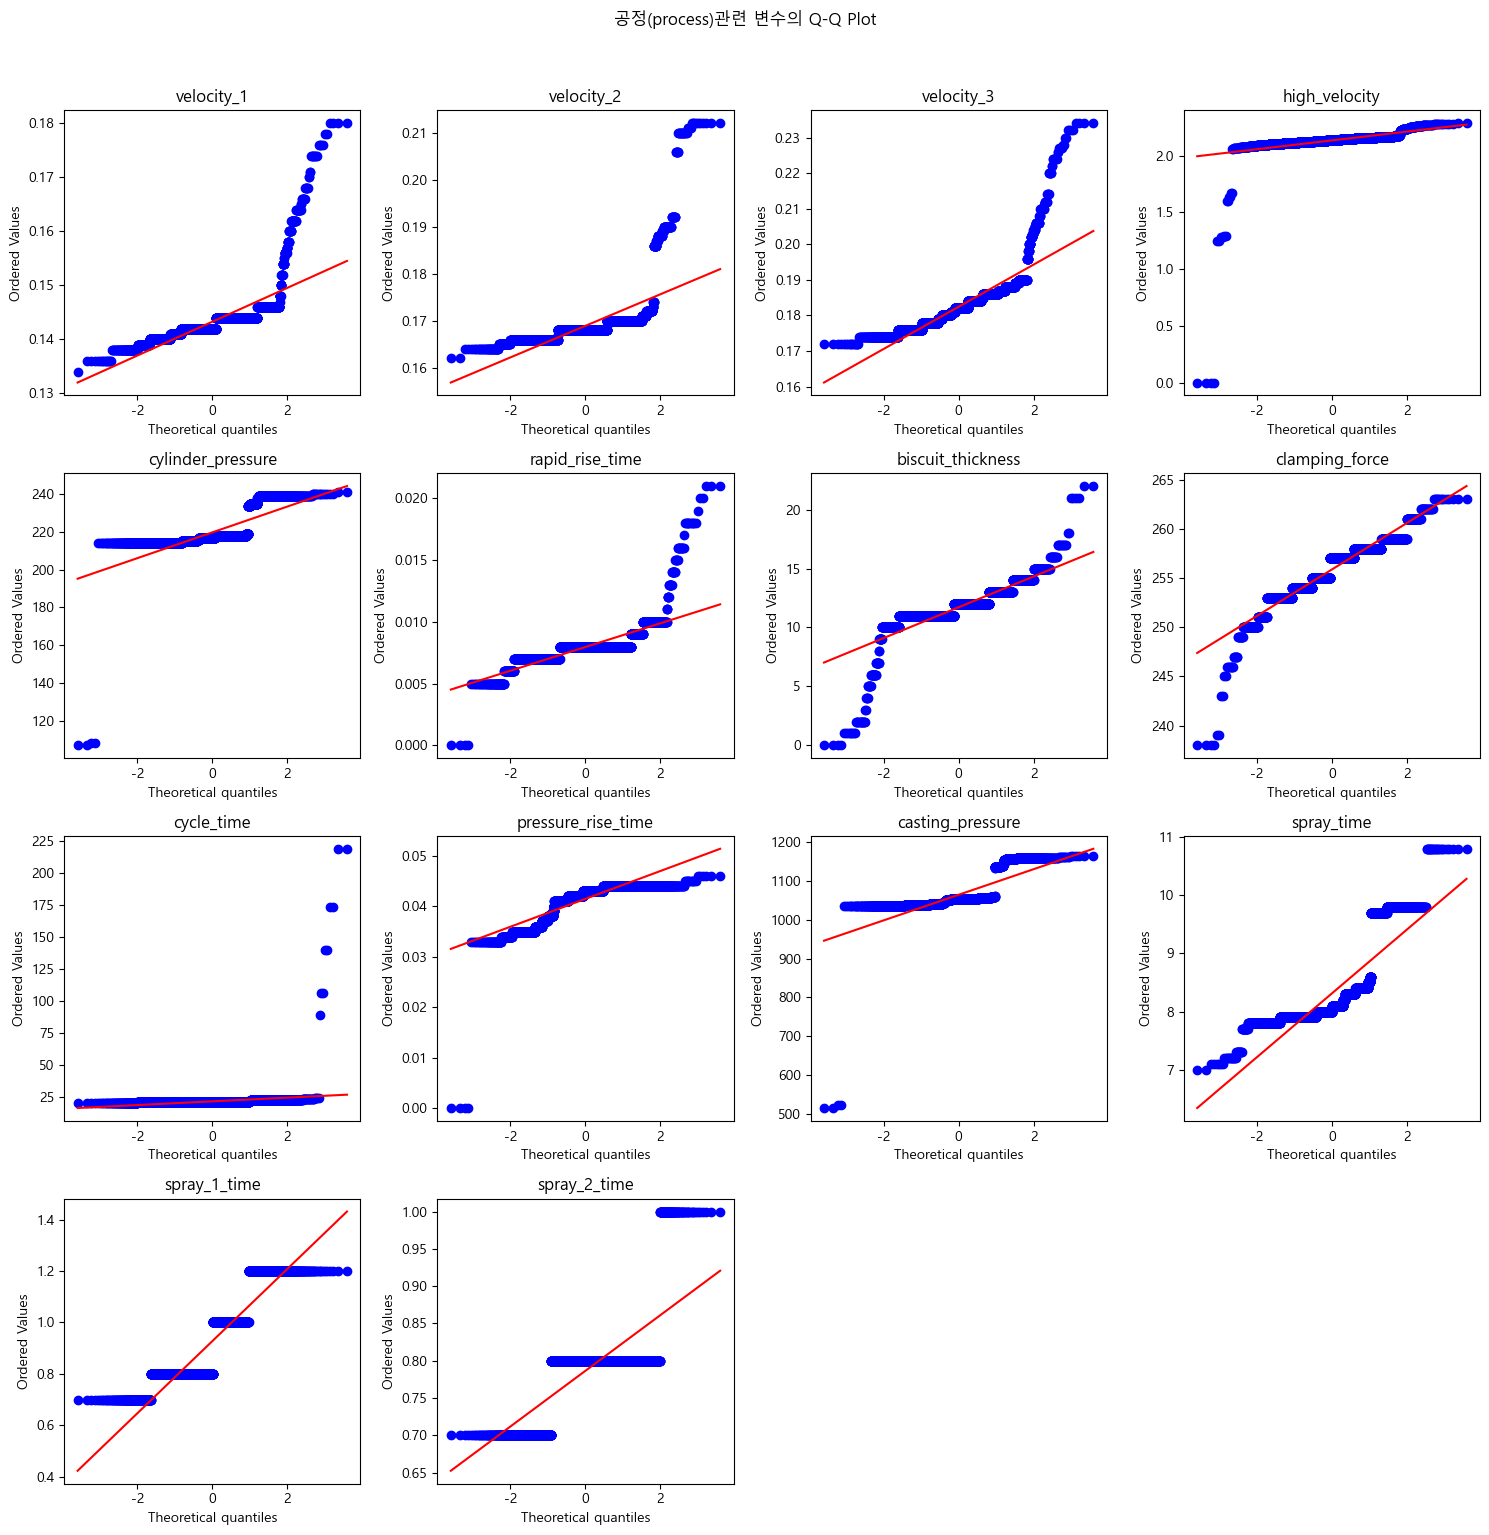

In [13]:
# 2. 함수 실행
plot_qq_table(df_process_1, 
            title="공정(process)관련 변수의 Q-Q Plot")

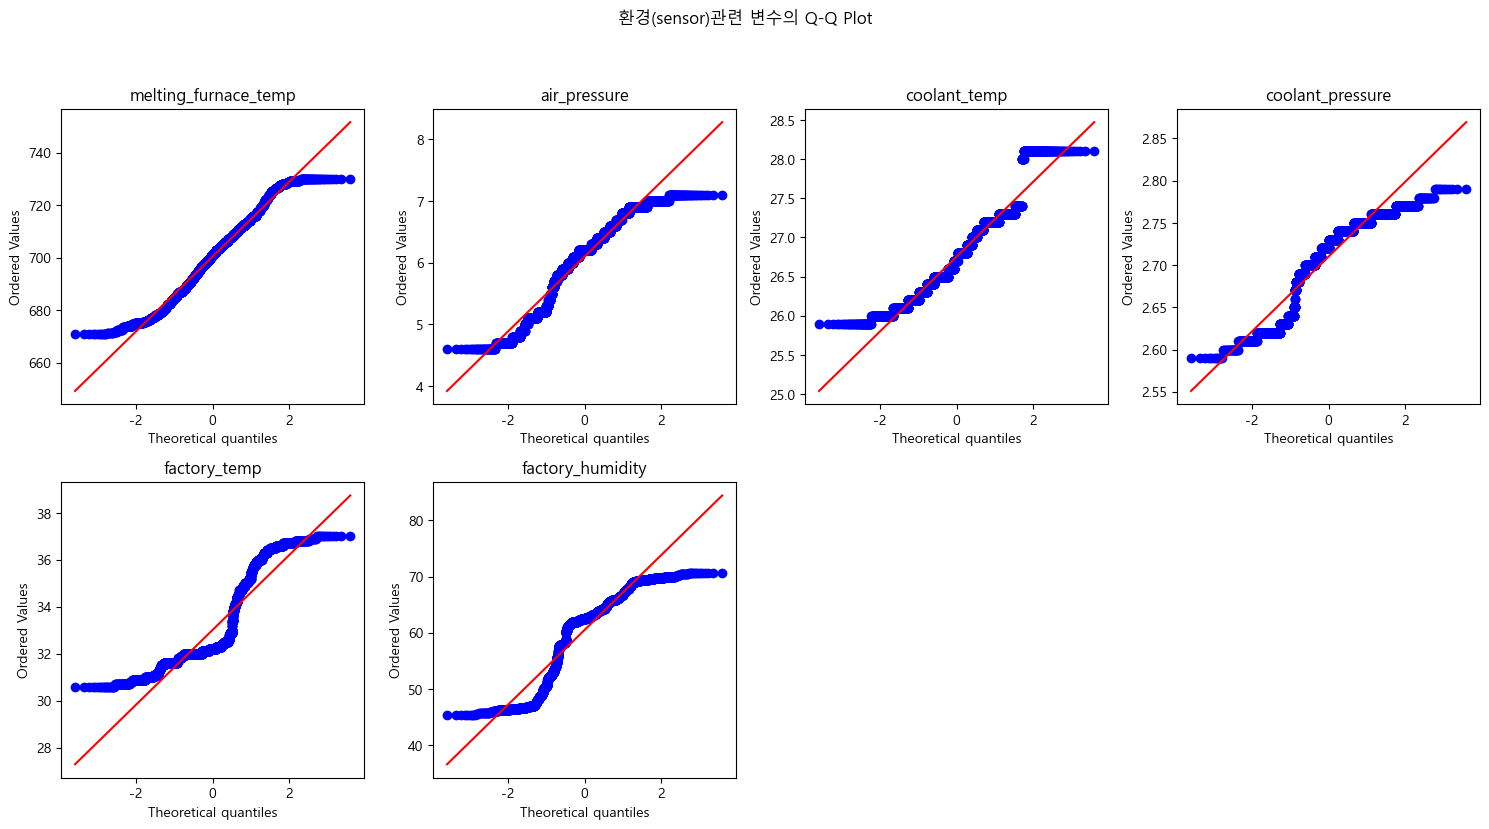

In [ ]:
plot_qq_table(df_sensor_1, 
            title="센서(sensor)관련 변수의 Q-Q Plot")

#### **3.3 정규성 검정 분석 결과**
**1. Shapiro-Wilk**\
공정 및 센서과 관련된 모든 변수에서 p-value가 거의 0으로 정규성을 만족하지 못한다.\
다만, 표본 수가 4,207개로 큰 편으로, Shapiro–Wilk 검정은 분포가 조금만 비대칭이거나 이산적이어도 정규성이 쉽게 기각될 수 있다.\
→ 따라서 p-value만 보고 "완전 비정규다"라 단정하기보단 Q-Q plot도 함께 확인하여 분포 형태를 종합적으로 해석하는 것이 적절하다.

2. **Q–Q plot 해석**
    1) **공정관련 변수의 Q–Q plot**: 값 대부분을 정규성 분포로 보기 어렵다.
        - 대부분 점들이 기준 직선 위에 고르게 놓이지 않고 중간 또는 꼬리 구간에서 이탈하는 모습이 확인되어 정규분포를 따른다 하기 어렵다.
        - 특히 일부 변수는 점들이 계단 형태로 나타나 연속형 정규분포로 보기 어려운 패턴이 관찰된다.
        (`velocity`, `rapid_rise_time` 등)
        - 즉, 공정 변수는 전반적으로 정규분포보다는 비대칭성, 반복값, 꼬리 이탈이 함께 나타나는 구조로 해석 가능하다.

    2) **센서관련 변수의 Q–Q plot**: 값 대부분을 정규성 분포로 보기 어렵다.
        - 직선에서 벗어나는 구간이 존재하며, 일부 변수는 꼬리 부분에서 이탈이 나타난다.
        - `factory_temp`, `factory_humidity는` 한쪽 꼬리가 더 길게 나타나는 비대칭성이 확인되며, 나머지 변수들도 완전한 정규분포라고 보기에는 어려운 형태를 보인다.
        - coolant_temp는 완만한 형태를 보이지만, 계단형 또는 곡선형 패턴이 나타나 완전한 정규분포와는 차이가 있다.
        - 센서변수의 특성상 데이터 분포상 꼬리가 생길 수 있으나 전반적으로 정규분포로 보기에는 부적합한 형태가 확인된다.

**3. 정규성 검정 결과 종합**\
제품유형 1의 공정 및 센서 변수는 Shapiro-Wilk 검정과 Q-Q plot을 종합했을 때, 전반적으로 정규분포를 따른다고 보기 어렵다.\
따라서 이후 집단 비교에서는 Welch’s t-test 결과를 참고하되 Mann-Whitney U 검정과 함께 해석하는 접근이 타당하다.

#### 3.4 Levene 검증

In [15]:
from scipy.stats import levene

# 1. 등분산성 검정 (Levene test)
def create_levene_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """등분산성 검정 (Levene test)"""
    print(f"\n{'='*80}")
    print(f"{df_name} 등분산성 검정 (Levene test) - 기준: {target_col}")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')    
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col]

    # 출력값 저장
    result_list = []
    
    # 각 컬럼별 등분산성 검정
    for col in df_copied.columns:
        group_0 = df_copied[target_series == 0][col].dropna()
        group_1 = df_copied[target_series == 1][col].dropna()
    
        # 등분산성 검정: levene
        stat, p_value = levene(group_0, group_1)

        # H0: 두 그룹의 분산이 같다 (등분산)
        # H1: 두 그룹의 분산이 다르다 (이분산)
        if p_value > alpha:
            result = "등분산 가정 가능"
        else:
            result = "등분산 가정 불가"

        # 출력할 값
        result_list.append([
            col, 
            stat, 
            p_value, 
            result
        ]
    )
    
    # 출력화면
    levene_df = pd.DataFrame(
        result_list,
        columns=[
            "변수명", 
            "Levene 통계량", 
            "p-value", 
            "판정"
        ]
    ).set_index("변수명")
    
    display(levene_df)
    
    return levene_df

In [16]:
# 2. 함수 실행
process_levene_surface = create_levene_summary(
    df_process_1,
    df_defects_1_1,
    "is_defect",
    "df_process_1",
    exclude_cols=['shot_key']
)


df_process_1 등분산성 검정 (Levene test) - 기준: is_defect



,Levene 통계량,p-value,판정
변수명,,,
velocity_1,21.089683,4.510936e-06,등분산 가정 불가
velocity_2,27.120408,2.003106e-07,등분산 가정 불가
velocity_3,26.808306,2.351704e-07,등분산 가정 불가
high_velocity,11.845690,5.835823e-04,등분산 가정 불가
cylinder_pressure,137.526513,2.825283e-31,등분산 가정 불가
rapid_rise_time,7.655019,5.686208e-03,등분산 가정 불가
biscuit_thickness,62.364014,3.615832e-15,등분산 가정 불가
clamping_force,51.845692,7.077913e-13,등분산 가정 불가
cycle_time,0.460697,4.973358e-01,등분산 가정 가능


In [17]:
process_levene_surface = create_levene_summary(
    df_sensor_1,
    df_defects_1_1,
    "is_defect",
    "df_sensor_1",
)


df_sensor_1 등분산성 검정 (Levene test) - 기준: is_defect



,Levene 통계량,p-value,판정
변수명,,,
melting_furnace_temp,31.602239,2.014701e-08,등분산 가정 불가
air_pressure,153.085205,1.456104e-34,등분산 가정 불가
coolant_temp,15.763107,7.298812e-05,등분산 가정 불가
coolant_pressure,123.729716,2.391456e-28,등분산 가정 불가
factory_temp,239.109585,1.672580e-52,등분산 가정 불가
factory_humidity,153.783089,1.037631e-34,등분산 가정 불가


#### **3.5 등분산성(Levene) 결과 해석**
**1. 공정관련 변수 (df_process)(is_defect 기준)**\
`cycle_time`을 제외한 모든 변수가 등분산 가정이 기각되었다.\
`cycle_time`은 p-value가 0.05보다 크게 나타나, 공정 변수 중에서는 예외적으로 등분산 가정이 성립할 가능성이 있는 변수로 확인되었다.\
따라서 공정관련 변수 (df_process)는 `cycle_time`을 제외한 변수는 등분산 가정이 기각되는 것으로 해석하는 것이 적절하다.

**2. 센서관련 변수(df_sensor) (is_defect 기준)**\
모든 항목에서 p-value가 매우 작아 등분산 가정이 모두 불가능한 것으로 판단된다.\
즉, sensor 데이터는 정상 제품과 불량 제품 간 분산 차이가 전반적으로 존재하는 것으로 해석할 수 있다.

**3. 등분산성 검정 결과 종합**\
제품유형 1에서는 공정 변수도 대부분 등분산 가정을 만족하지 못했고, 센서 변수는 전반적으로 모두 등분산 가정이 성립하지 않았다.\
따라서 이후 정상/불량 간 평균 비교에서는 등분산을 가정하는 Student's t-test보다 Welch's t-test를 사용하는 것이 더 적절하다.\
또한 정규성도 충분히 만족하지 않았기 때문에, Welch's t-test 결과와 함께 Mann-Whitney U 검정 결과도 병행하여 해석하는 흐름이 타당하다.

#### 3.6 스피어만 상관계수 히트맵

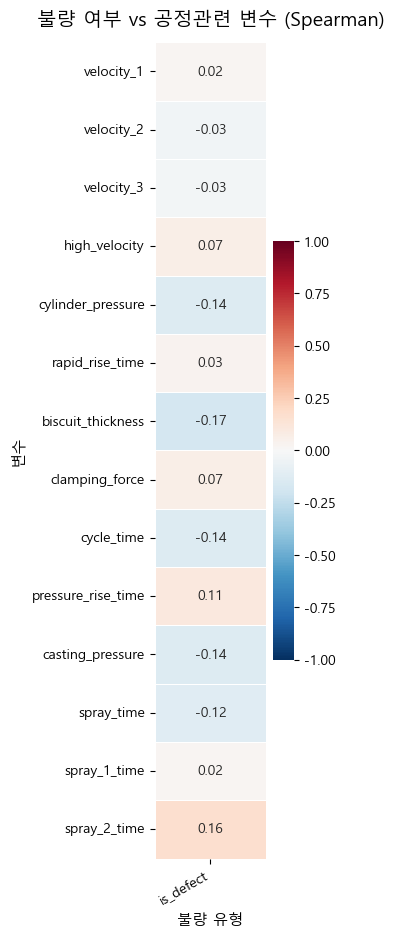

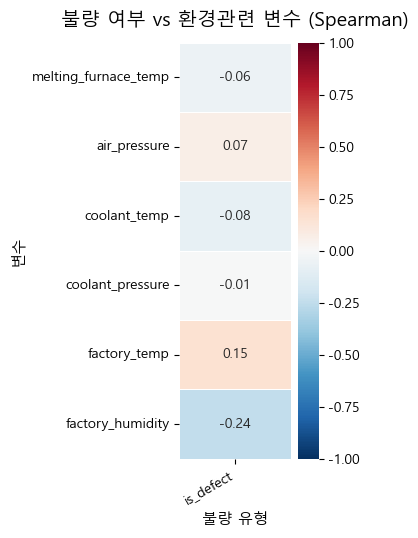

In [ ]:
# 1. 변수 정의
DEFECT_COLS = ['is_defect']

PROCESS_COLS = [
    'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
    'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
    'clamping_force', 'cycle_time', 'pressure_rise_time',
    'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time',
]

SENSOR_COLS = [
    'melting_furnace_temp', 'air_pressure', 'coolant_temp', 'coolant_pressure',
    'factory_temp', 'factory_humidity'
]

# 2. 스피어만 상관계수 히트맵 시각화 함수
def plot_corr_heatmap(df, defect_cols, feature_cols, title):
    corr = df[defect_cols + feature_cols].corr(method='spearman')
    corr_target = corr.loc[feature_cols, defect_cols]

    fig, ax = plt.subplots(
        figsize=(len(defect_cols) * 1.8, len(feature_cols) * 0.65 + 1.5)
    )

    sns.heatmap(
        corr_target,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel('불량 유형', fontsize=11)
    ax.set_ylabel('변수', fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# 3. 함수 출력
plot_corr_heatmap(df_original_1_1, DEFECT_COLS, PROCESS_COLS, '불량 여부 vs 공정관련 변수 (Spearman)')
plot_corr_heatmap(df_original_1_1, DEFECT_COLS, SENSOR_COLS, '불량 여부 vs 센서관련 변수 (Spearman)')

#### **3.7 스피어만 상관계수 해석**
제품유형 1에서 공정/센서 변수 모두에서 상관계수 절댓값이 대체로  0.00 ~ 0.24 수준으로 크지 않게 나타났으며,\
전체적으로 단일 변수 1개가 불량 여부를 강하게(단조롭게) 설명하는 관계는 약한 편이다.

즉, 불량은 단일 변수보다는 복합적인 조건(조합/임계값/비선형 관계)의 영향을 받을 가능성이 있어\
각 변수와 불량 여부 컬럼의 상관관계만으로 "불량의 원인"을 단정하지 않고,\
통계적 검정(Welch's T 검정/Mann-Whitney U 검정)방법과 머신러닝 모델 기반 중요도에서 함께 판단하는것이 적절하다고 판단된다.

#### 3.8 결측치 개수 확인
- 통계적 검정방법을 수행하기 전, 결측치 개수 확인

In [19]:
# 1. 결측치 확인
print("\n=== 전체 데이터 기준 결측치 개수 ===")
print(f"{df_original_1_1.isnull().sum().sum()}개")


=== 전체 데이터 기준 결측치 개수 ===
0개


#### 3.9 Box Plot

In [20]:
# 1. box plot 시각화 함수 정의
import math

def plot_boxplots(df, cols, group_title):
    
    # is_defect를 문자열로 변환
    df_a = df.copy()
    df_a["is_defect"] = df["is_defect"].map({0: "정상", 1: "불량"})
    
    n_rows = math.ceil(len(cols) / 4)

    fig, axes = plt.subplots(n_rows, 4, figsize=(20, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        sns.boxplot(
            x="is_defect", y=col,
            data=df_a,
            palette={"정상": "#4C72B0", "불량": "#DD8452"},
            ax=axes[i]
        )
        axes[i].set_title(col, fontsize=11, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].set_xticklabels(["정상", "불량"], fontsize=10)

    # 비어있는 subplot 숨기기
    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"[{group_title}] 정상 vs 불량 분포 비교", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    return df_a

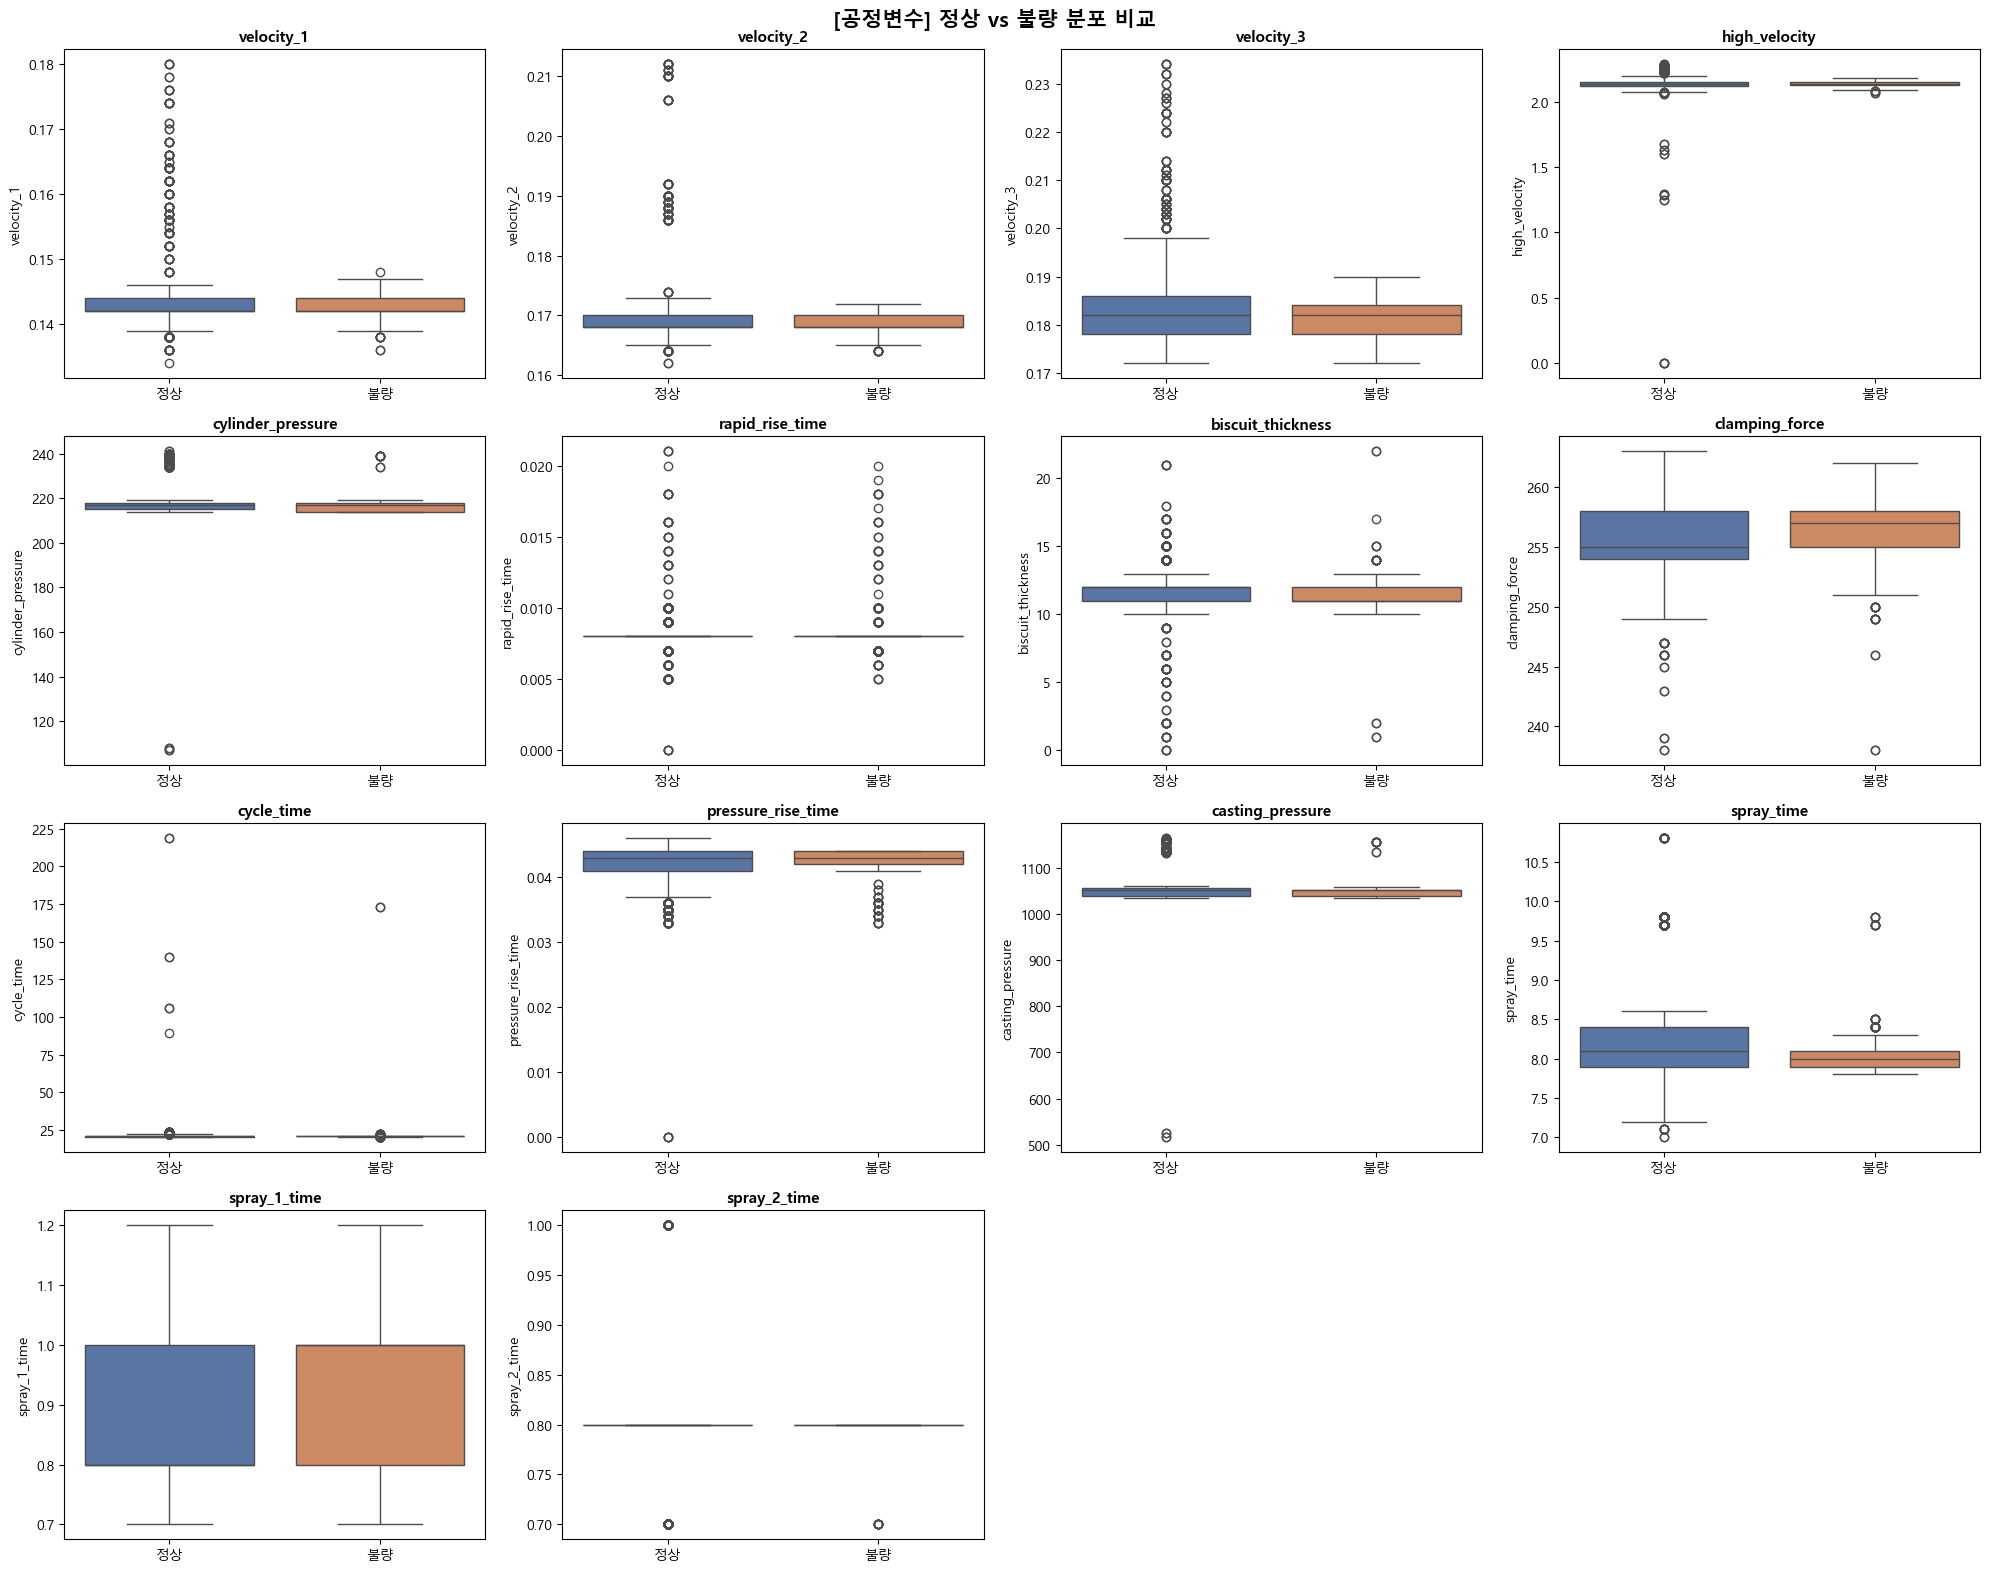

In [21]:
# 2. 함수 실행
boxplot_of_process_1 = plot_boxplots(df_original_1_1, PROCESS_COLS, "공정변수")

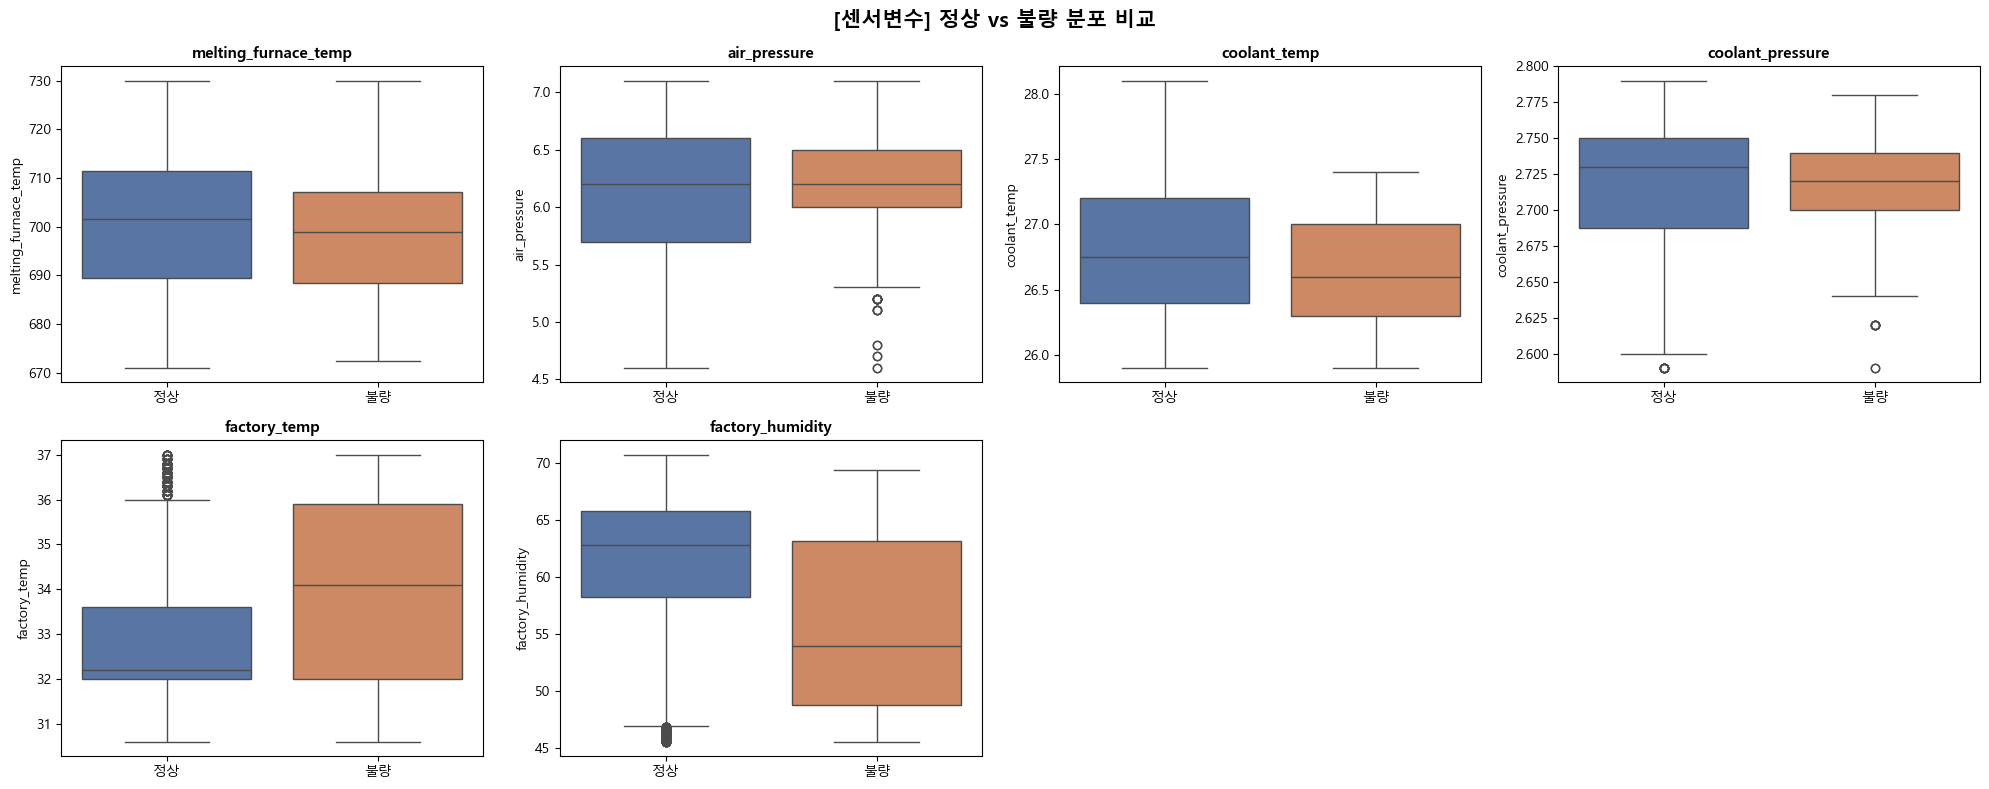

In [22]:
boxplot_of_sensor_1 = plot_boxplots(df_original_1_1, SENSOR_COLS, "센서변수")

#### **3.10 박스플롯 해석**
1. **공정관련 변수 (df_process) 관점**
    - `spray_time`: 불량 집단의 중앙값이 정상 집단보다 조금 낮은 방향으로 이동해 보여, 공정 변수 중에서는 정상/불량 차이가 비교적 직관적으로 확인되는 변수이다.
    - `casting_pressure` / `cylinder_pressure`: 중앙값 차이는 크지 않더라도 분포 폭이나 꼬리(이상치) 양상이 다르게 나타나 두 집단의 분포 구조가 완전히 같지는 않음을 보여준다.
    - 공정 변수에서는 `spray_time`이 가장 직관적인 후보이며, 나머지는 중앙값 차이보다는 분포 모양과 이상치 차이를 함께 보는 해석이 적절하다.


2. **센서관련 변수(df_sensor) 관점**
    - `factory_humidity`: 불량 집단의 중앙값이 정상 집단보다 확실히 낮고, 박스 폭과 전체 분포 양상도 달라져 가장 눈에 띄는 변수로 해석할 수 있다
    - `factory_temp`: 불량 그룹이 정상보다 높은 쪽으로 이동하는 경향을 보인다.
    - 센서 변수 중 `factory_humidity`(가장 뚜렷), `factory_temp`에서 정상/불량 분포 차이가 비교적 명확하다.

3. **박스플롯 해석 종합**\
제품유형 1의 박스플롯은 공정 변수보다 센서 변수에서 정상/불량 간 차이가 조금 더 분명하게 나타나는 경향을 보여준다.\
다만 전반적으로 분포 겹침도 적지 않으므로,\
실제 유의한 차이 여부는 Welch's t-test와 Mann-Whitney U 검정 결과를 함께 확인하는 것이 적절하다.

---
---
### 4. 통계적 검정

#### 4.1 Welch's T-test

In [23]:
# 1. 효과크기 해석 함수
def cohens_d_ind(group1, group2): # 독립표본 d(합동표준편차 사용)
    """Cohen's d — 독립표본: d = |x̄₁ - x̄₂| / s_pooled"""
    n1, n2 = len(group1), len(group2)
    var1 = np.var(group1, ddof=1)
    var2 = np.var(group2, ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)) # 합동 분산 
    return abs(np.mean(group1) - np.mean(group2)) / s_pooled

In [24]:
from scipy.stats import ttest_ind

# 2. Welch t-test 검정 + Cohen's d 효과크기
def create_welch_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """Welch t-검정 및 효과크기"""
    print(f"\n{'='*80}")
    print(f"{df_name} 실제 집단 차이 검정 (Welch t-test) - 기준: {target_col}")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col].reindex(df_copied.index)

    # 출력값 저장
    result_list = []
    
    for col in df_copied.columns:
        group_0 = df_copied.loc[target_series == 0, col].dropna()
        group_1 = df_copied.loc[target_series == 1, col].dropna()
    
        # 통계검정: Welch t-검정 (등분산 가정 X)
        # 양측검정 (two-sided)
        t_stat, p_value = ttest_ind(group_0, group_1, equal_var=False, alternative='two-sided')
        
        # 효과크기: Cohen's d
        cohen_d = cohens_d_ind(group_0, group_1)
    
        # 가설검정 판정
        # alpha 변환 가능
        # 귀무가설(H0): 두 집단의 평균이 같다. (μ0 = μ1)
        # 대립가설(H1): 두 집단의 평균이 다르다. (μ0 ≠ μ1)
        if p_value >= alpha:
            result = False
        else:
            result = True

        # 효과크기 판정 = 기준은 유동적
        if abs(cohen_d) < 0.1:
            effect = "매우 작은 효과"
        elif abs(cohen_d) < 0.3:
            effect= "작은 효과"
        elif abs(cohen_d) < 0.5:
            effect = "중간 효과"
        else:
            effect = "큰 효과"
        
        # 출력할 값
        result_list.append([
            col,
            t_stat,
            cohen_d,
            effect,
            p_value,
            result
        ])


    # 출력화면 조정
    welch_df = pd.DataFrame(
        result_list,
        columns=[
            "변수",
            "t-통계량", 
            "Cohen's d", 
            "효과크기 판정",
            "p-value", 
            "통계적 유의성 여부"
        ]
    ).set_index("변수")
    
    # 효과크기의 절대값을 기준으로 내림차순 정렬
    welch_df = welch_df.sort_values("Cohen's d", key=abs, ascending=False)
    display(welch_df)
    
    return welch_df

In [25]:
welch_surface = create_welch_summary(
    df_original_1_1,
    df_defects_1_1,
    "is_defect",
    "df_original_1_1",
    exclude_cols=['shot_key', 'is_defect']
)


df_original_1_1 실제 집단 차이 검정 (Welch t-test) - 기준: is_defect



,t-통계량,Cohen's d,효과크기 판정,p-value,통계적 유의성 여부
변수,,,,,
factory_humidity,17.666572,0.787358,큰 효과,6.858484e-61,True
factory_temp,-12.190926,0.575871,큰 효과,7.551833e-32,True
spray_time,21.334894,0.493985,중간 효과,7.577529e-95,True
casting_pressure,20.087005,0.449190,중간 효과,2.833432e-85,True
cylinder_pressure,19.982427,0.448674,중간 효과,2.077401e-84,True
pressure_rise_time,-11.514724,0.346388,중간 효과,1.394746e-29,True
spray_2_time,-14.221246,0.290758,작은 효과,7.310036e-45,True
coolant_temp,7.115402,0.256446,작은 효과,1.886563e-12,True
biscuit_thickness,7.629299,0.254979,작은 효과,4.375297e-14,True


#### **4.2 Welch's t-test 결과 해석 (α=0.05)**

1. **공정관련 변수 (df_process)**
    1) 유의하게 나온 변수
        - `spray_time`, `casting_pressure`, `cylinder_pressure`, `pressure_rise_time`, `velocity_2`, `velocity_3`, `rapid_rise_time`, `biscuit_thickness`, `clamping_force`, `high_velocity`, `spray_2_time`

    2) 유의하지 않게 나온 변수
        - `spray_1_time`, `cycle_time`

    3) 효과크기 관점
        - 중간 이상의 효과 크기를 가진 변수 `spray_time`, `casting_pressure`, `cylinder_pressure`, `pressure_rise_time`이 상대적으로 큰 편으로 나타나 불량/정상 집단을 구분하는 신호가 비교적 뚜렷한 변수로 해석할 수 있다.
        - `high_velocity`는 유의하긴 했지만 매우 작은 효과로 나타나, 실제 차이의 크기는 크지 않다고 해석하는 것이 적절하다.
    4) 방향성
        - 정상군 평균이 더 높은 변수: `spray_time`, `casting_pressure`, `cylinder_pressure`, `velocity_1`, `velocity_2`, `velocity_3`, `biscuit_thickness`
        - 불량군 평균이 더 높은 변수: `pressure_rise_time`, `rapid_rise_time`, `clamping_force`, `high_velocity`, `spray_2_time`


2. **센서관련 변수(df_sensor)**
    1) 유의하게 나온 변수
       - 센서 변수는 전부 유의로 나왔다.
    
    2) 유의하지 않게 나온 변수
        - 센서 변수는 전부 유의로 나왔다.

    2) 효과크기 관점
        - `factory_humidity`, `factory_temp` 는 큰 효과로 나타나 센서 변수 중 정상/불량 차이가 특히 뚜렷한 변수로 볼 수 있다.
        - 그 외의 변수들은 작은 효과 수준으로, 유의하더라도 차이의 크기는 상대적으로 제한적이다.
    4) 방향성
        - 정상군 평균이 더 높은 변수: `factory_humidity`, `coolant_temp`, `melting_furnace_temp`
        - 불량군 평균이 더 높은 변수: `factory_temp`, `air_pressure`, `coolant_pressure`

3. **Welch's t 검정 결과 종합**
- Product type_1에서는 다음 변수가 불량 그룹과 정상 그룹을 구분하는 후보 변수로 보인다.\
    - 공정(df_process): `spray_time`, `casting_pressure`, `cylinder_pressure`, `pressure_rise_time`
    - 센서(df_sensor): `factory_humidity`, `factory_temp`
- - 다만 큰 표본의 영향으로 작은 차이도 유의할 수 있으므로, 효과크기와 비모수 검정을 함께 해석해야 한다.

#### 4.3 Mann-Whitney U 검정

In [26]:
from scipy.stats import mannwhitneyu
import pingouin as pg

# 1. Mann-Whitney U 검정 + rank-biserial 효과크기
def create_mannwhitney_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """mannwhitney u-검정 및 효과크기"""
    print(f"\n{'='*80}")
    print(f"{df_name} 실제 집단 차이 검정 (Mann-Whitney U) - 기준: {target_col}")
    print(f"{'='*80}\n")

    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col].reindex(df_copied.index)

    # 출력값 저장
    result_list = []
    
    for col in df_copied.columns:
        group_0 = df_copied.loc[target_series == 0, col].dropna()
        group_1 = df_copied.loc[target_series == 1, col].dropna()

        # Mann–Whitney U
        # 입력 순서가 중요 group_1을 먼저 넣으면, RBC 부호 해석이 직관적이 됨
        #  RBC > 0  → 불량(1) 그룹 값이 더 큰 경향
        #  RBC < 0  → 불량(1) 그룹 값이 더 작은 경향

        # Pingouin(pg.mwu)은 U 통계량, p-value, 효과크기(RBC)를 한 번에 반환함
        out = pg.mwu(group_1, group_0, alternative='two-sided')
        u_stat  = out["U_val"].values[0] # u_stat
        p_value = out["p_val"].values[0] # p_value
        # 효과크기: rank-biserial correlation
        rbc = out["RBC"].values[0] # rbc 
        
        # 가설검정 판정
        # alpha 변환 가능
        # 귀무가설(H0): 두 집단의 분포가 같다. (순위가 비슷하다)  → 차이가 없다
        # 대립가설(H1): 두 집단의 분포가 다르다. (순위가 다르다) → 차이가 있다
        if p_value >= alpha:
            result = False
        else:
            result = True

        # 효과크기 판정 = 기준은 유동적
        if abs(rbc) < 0.1:
            effect = "매우 작은 효과"
        elif abs(rbc) < 0.3:
            effect= "작은 효과"
        elif abs(rbc) < 0.5:
            effect = "중간 효과"
        else:
            effect = "큰 효과"
        
        # 출력할 값
        result_list.append([
            col, 
            u_stat, 
            rbc,
            effect,
            p_value, 
            result
        ])
    
    # 출력화면
    mannwhitney_df = pd.DataFrame(
        result_list,
        columns=[
                "변수", 
                "U-통계량", 
                "rank-biserial", 
                "효과크기 해석",
                "p-value",
                "통계적 유의성 여부"
            ]
    ).set_index("변수")
    
    # 효과크기의 절대값을 기준으로 내림차순 정렬
    mannwhitney_df = mannwhitney_df.sort_values('rank-biserial', key=abs, ascending=False)
    display(mannwhitney_df)
    
    return mannwhitney_df


In [27]:
mannwhitney_surface = create_mannwhitney_summary(
    df_original_1_1,
    df_defects_1_1,
    "is_defect",
    "df_original_1_1",
    exclude_cols=['shot_key', 'is_defect']
)


df_original_1_1 실제 집단 차이 검정 (Mann-Whitney U) - 기준: is_defect



,U-통계량,rank-biserial,효과크기 해석,p-value,통계적 유의성 여부
변수,,,,,
factory_humidity,809960.5,-0.367923,중간 효과,9.742081e-56,True
biscuit_thickness,962926.0,-0.248551,작은 효과,3.104061e-29,True
factory_temp,1574137.0,0.228426,작은 효과,1.190131e-22,True
cycle_time,1011213.0,-0.210869,작은 효과,9.834487e-20,True
casting_pressure,1011287.0,-0.210811,작은 효과,1.704276e-19,True
cylinder_pressure,1023400.0,-0.201358,작은 효과,1.475993e-18,True
spray_time,1048323.0,-0.181909,작은 효과,3.323566e-15,True
spray_2_time,1505490.0,0.174855,작은 효과,1.243913e-26,True
pressure_rise_time,1481562.5,0.156183,작은 효과,8.391748e-12,True


#### **4.4 Mann-Whitney U 결과 분석**

1. **공정관련 변수(df_process)**
    - `biscuit_thickness`: RBC -0.249 → 불량(1) 그룹에서 값이 낮은 쪽으로 치우치는 경향 / 작은 효과(공정 중 상위권)
    - `cycle_time`: RBC -0.211 → 불량에서 낮은 쪽 / 작은 효과
    - `casting_pressure`: RBC -0.211 → 불량에서 낮은 쪽 / 작은 효과
    - `cylinder_pressure`: RBC ≈ -0.201 → 불량에서 낮은 쪽 / 작은 효과

2. **센서관련 변수(df_sensor) 관점**
    - `factory_humidity`: RBC -0.368 → 불량에서 값이 낮은 쪽으로 치우침 / 중간 효과(가장 강함)
    - `factory_temp`: RBC +0.228 → 불량에서 값이 높은 쪽 / 작은 효과

3. **Mann-Whitney U 검정 결과 종합**
    1) 공정관련 변수 후보(우선순위)
        - 1순위: `biscuit_thickness` (변수 중 가장 큰 효과크기를 갖고 있음)
        - 2순위: `cycle_time`, `casting_pressure`, `cylinder_pressure`, `spray_time`
        - 보조 후보: `spray_2_time`, `pressure_rise_time`

    2) 센서관련 변수 후보(우선순위)
        - 1순위: `factory_humidity` (변수 중 가장 큰 효과크기를 갖고 있음)
        - 2순위: `factory_temp`
        - 보조 후보: `coolant_temp`

---
---
### **5. 종합 분석**
제품유형 1에서 Welch's t-test와 Mann–Whitney U 검정을 통합한 결과...

공정관련 변수(df_process)에서는 **spray_time, casting_pressure, cylinder_pressure, pressure_rise_time**이
정상/불량 집단을 비교적 일관되게 구분하는 핵심 후보 변수로 확인되었다.\
**biscuit_thickness, spray_2_time**은 보조 후보로 함께 고려할 수 있다.

센서관련 변수(df_sensor)에서는 **factory_humidity**와 **factory_temp**가 주요 후보로 나타났다.\
**coolant_temp**는 보조 후보로 고려할 수 있다.

따라서 제품유형 1의 불량은 특정 단일 변수보다는 공정·센서 변수들의 복합적인 작용으로 설명하는 것이 타당하다.